# Edge Load Status — Feature Distribution EDA

Target: `load_status` (e.g., low, medium, high). This notebook loads the dataset from the Hugging Face Hub and visualizes feature distributions conditioned on the target.

In [78]:
pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from huggingface_hub import HfFileSystem, hf_hub_download
import fsspec
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.autolayout"] = True

SAVE_FIGS = True
FIGURES_DIR = Path("../figures")

def maybe_savefig(name: str):
    if SAVE_FIGS:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

In [80]:
# Load dataset via hf:// path with safe fallbacks
import pandas as pd
import numpy as np


PARQUET_URL = "hf://datasets/electricsheepafrica/nigerian-telecom-edge-computing-load-data/edge_computing_load_data.parquet"
CSV_URL = "hf://datasets/electricsheepafrica/nigerian-telecom-edge-computing-load-data/edge_computing_load_data.csv"
src = None

try:
    df = pd.read_parquet(PARQUET_URL)
except Exception as e_parq:
    print("Unable to load Parquet..", str(e_parq))
    try:
        df = pd.read_csv(CSV_URL)
    except Exception as e_csv:
        print("Unable to load CSV..", str(e_csv))
        raise


if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

for col in ['edge_node_id', 'city', 'application', 'operator', 'load_status']:
    if col in df.columns:
        try:
            df[col] = df[col].astype('category')
        except Exception:
            pass

# Target distribution
if 'load_status' in df.columns:
    print("load_status distribution (counts):\n", df['load_status'].value_counts(dropna=False))
    print("load_status distribution (proportions):\n", df['load_status'].value_counts(normalize=True, dropna=False).round(3))
else:
    print("Warning: target 'load_status' not found.")

load_status distribution (counts):
 load_status
low       124720
medium     98416
high       26864
Name: count, dtype: int64
load_status distribution (proportions):
 load_status
low       0.499
medium    0.394
high      0.107
Name: proportion, dtype: float64


In [81]:
# Select metrics for analysis (prefer meaningful columns if present)
preferred = [
    'cpu_utilization_percent','memory_utilization_percent','storage_utilization_percent',
    'network_throughput_gbps','active_sessions','requests_per_second',
    'avg_response_time_ms','cache_hit_ratio_percent'
]
metrics = [c for c in preferred if c in df.columns]
if not metrics:
    metrics = numeric_cols
print("Metrics used:", metrics)

Metrics used: ['cpu_utilization_percent', 'memory_utilization_percent', 'storage_utilization_percent', 'network_throughput_gbps', 'active_sessions', 'requests_per_second', 'avg_response_time_ms', 'cache_hit_ratio_percent']


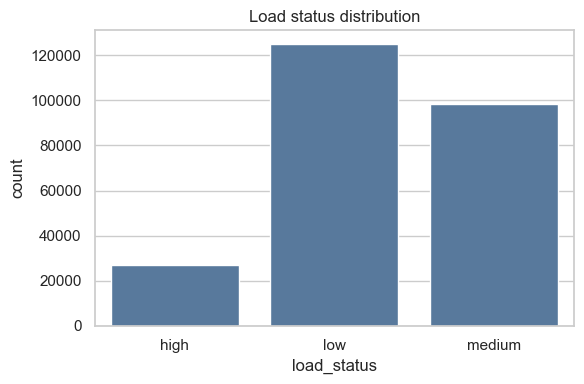

In [82]:
# Target distribution plot
if 'load_status' in df.columns:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else None
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='load_status', order=order, color='#4C78A8')
    plt.title('Load status distribution')
    maybe_savefig('ls_counts')
    plt.show()
else:
    print("Target 'load_status' not found.")

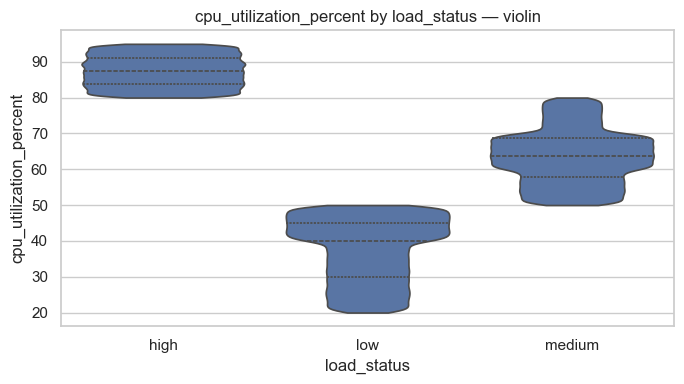

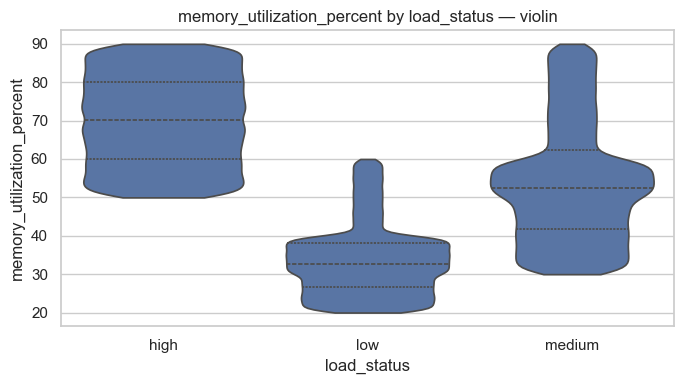

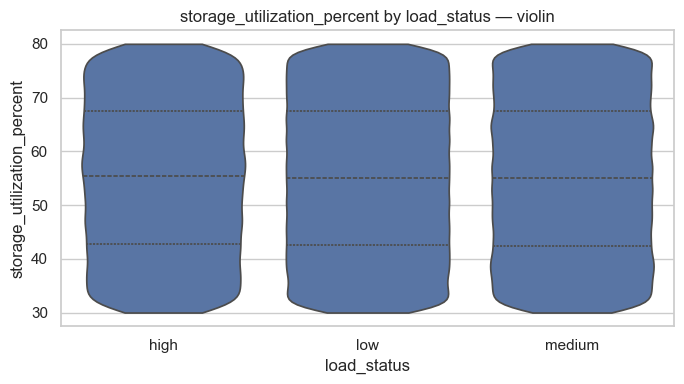

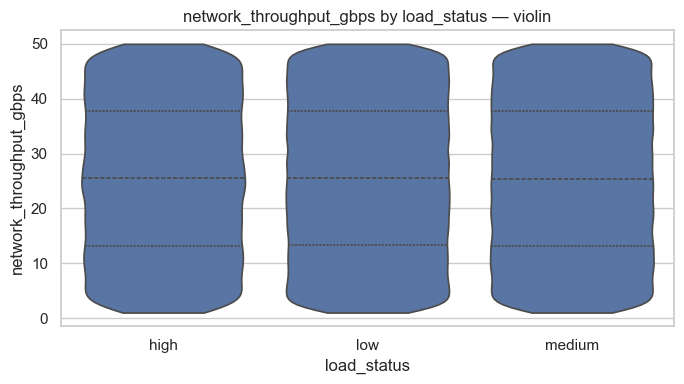

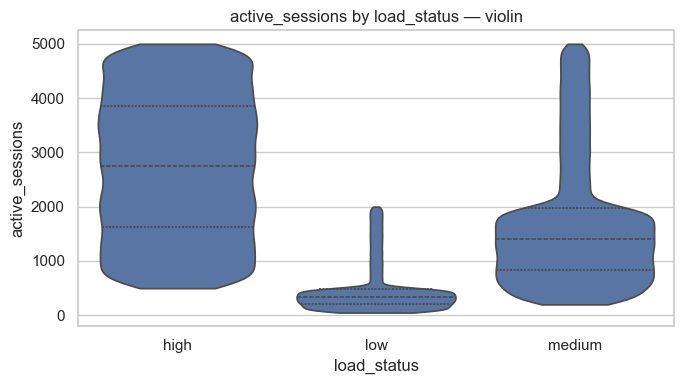

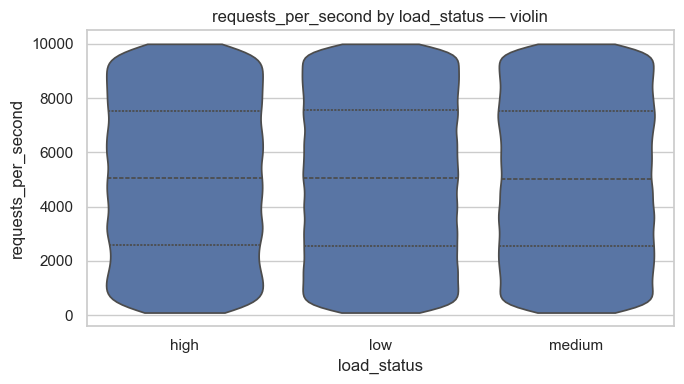

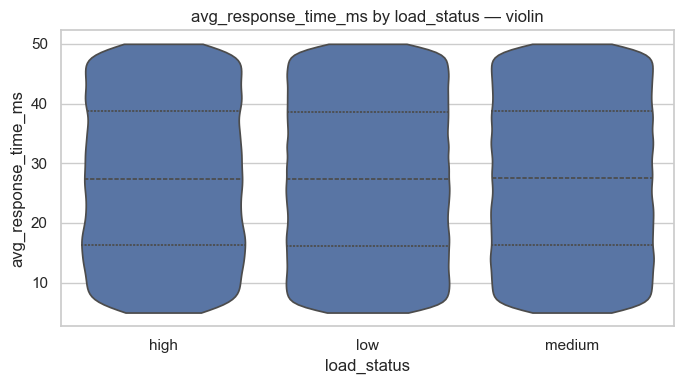

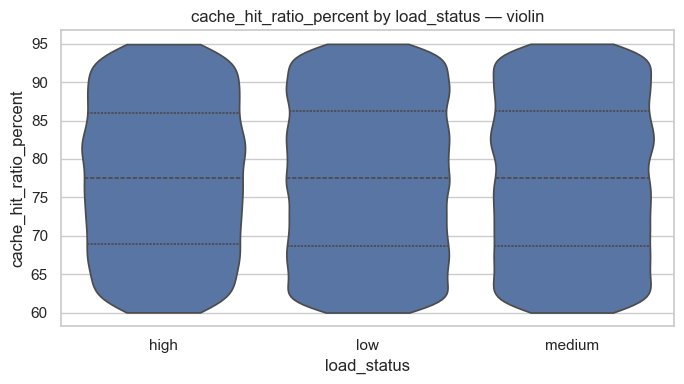

In [83]:
# Numeric distributions by load_status — violin plots with quartiles
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    for col in metrics:
        plt.figure(figsize=(7,4))
        sns.violinplot(data=df, x='load_status', y=col, inner='quartile', cut=0, scale='width')
        plt.title(f"{col} by load_status — violin")
        maybe_savefig(f"violin_{col}")
        plt.show()

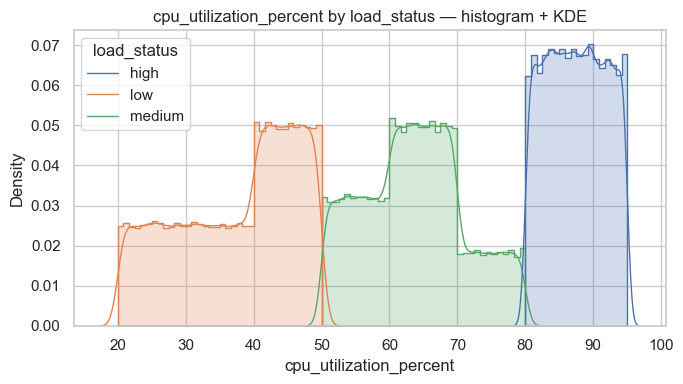

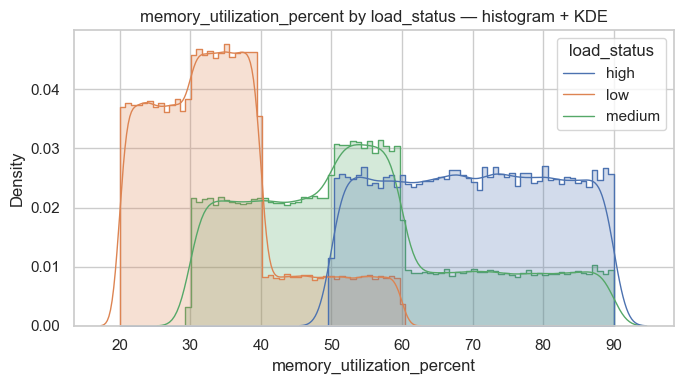

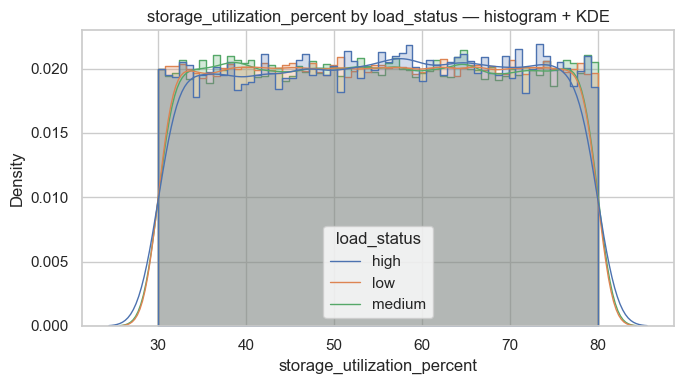

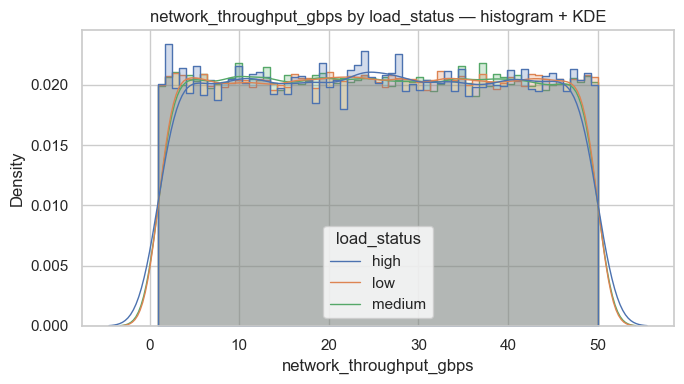

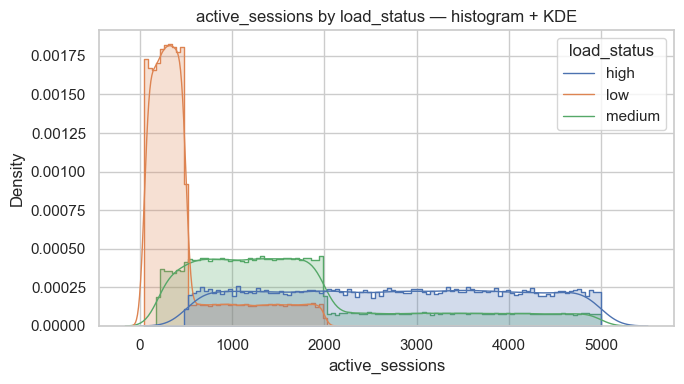

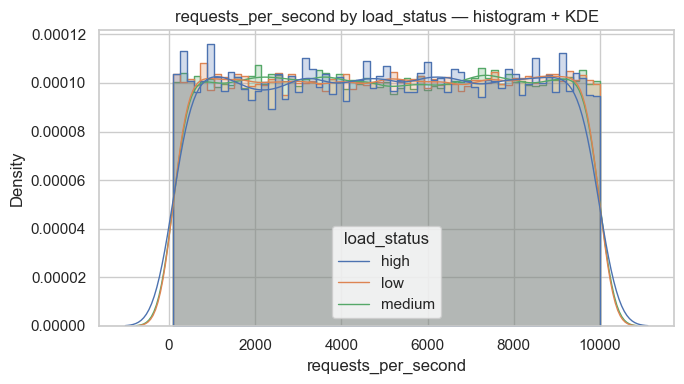

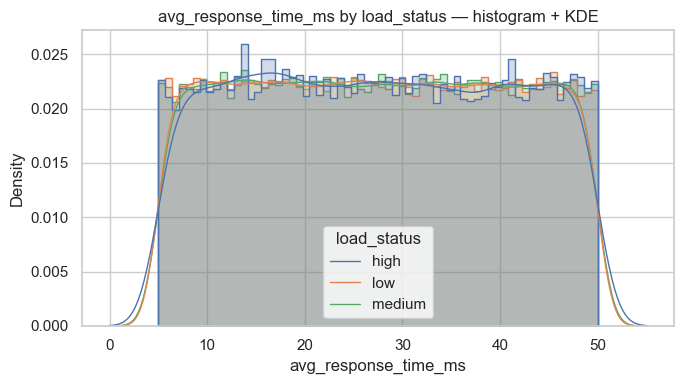

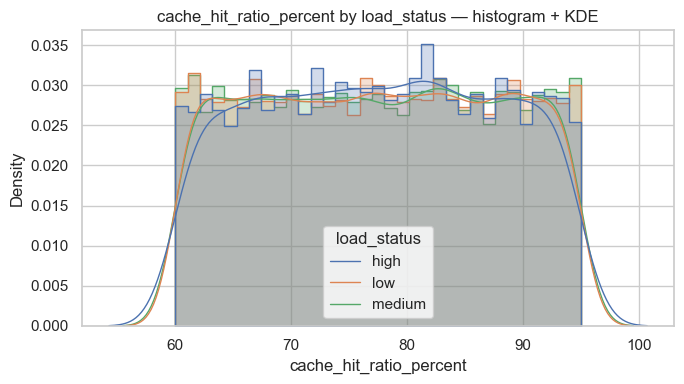

In [84]:
# Numeric distributions by load_status — overlaid histograms (density)
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    for col in metrics:
        plt.figure(figsize=(7,4))
        sns.histplot(data=df, x=col, hue='load_status', stat='density', common_norm=False,
                     element='step', fill=True, alpha=0.25)
        sns.kdeplot(data=df, x=col, hue='load_status', common_norm=False, lw=1)
        plt.title(f"{col} by load_status — histogram + KDE")
        maybe_savefig(f"hist_{col}_by_ls")
        plt.show()

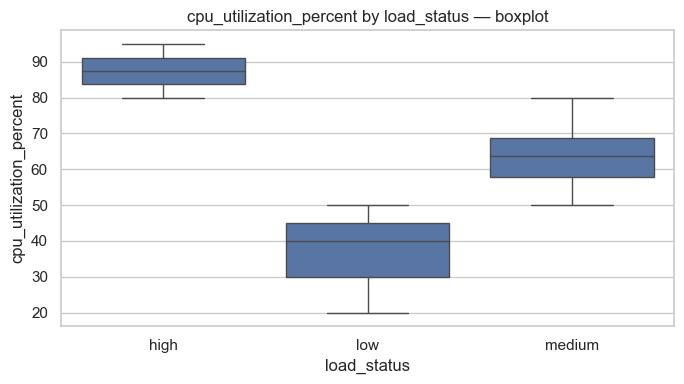

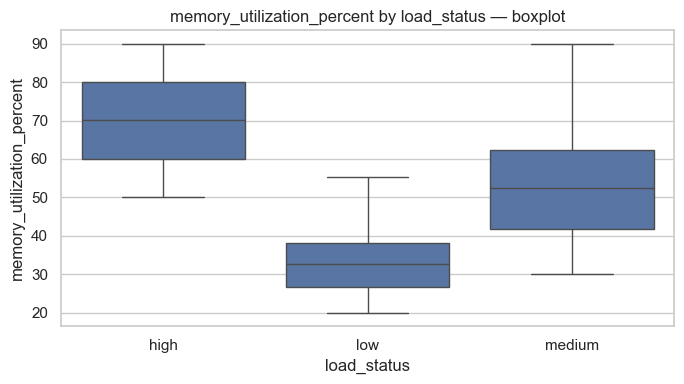

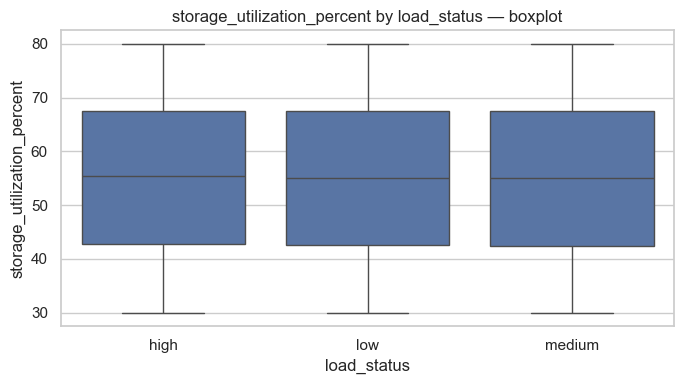

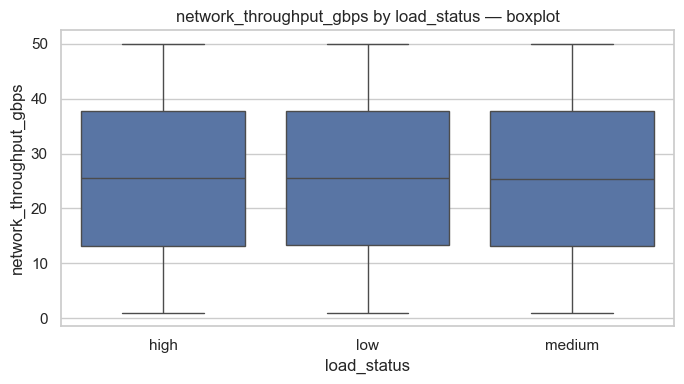

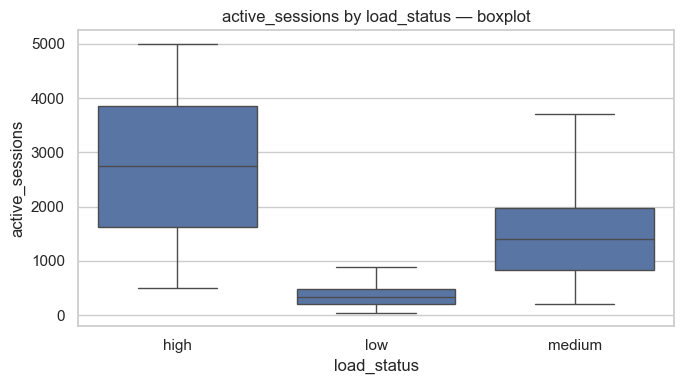

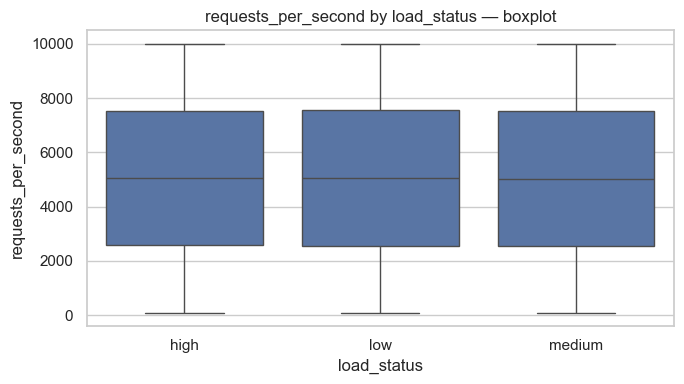

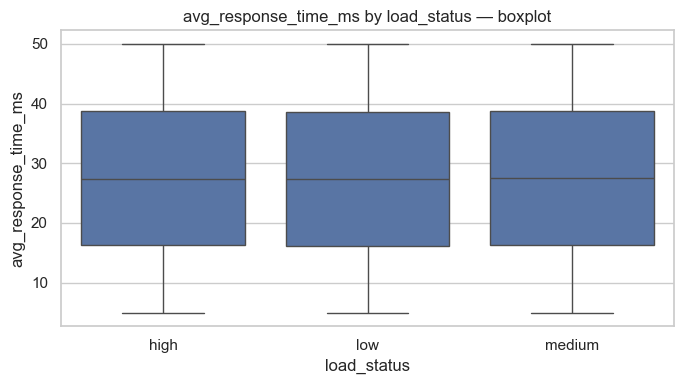

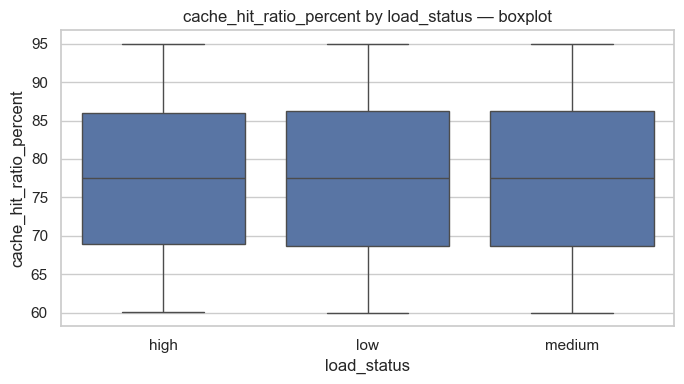

In [85]:
# Numeric distributions by load_status — boxplots (fliers hidden)
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    for col in metrics:
        plt.figure(figsize=(7,4))
        sns.boxplot(data=df, x='load_status', y=col, showfliers=False)
        plt.title(f"{col} by load_status — boxplot")
        maybe_savefig(f"box_{col}")
        plt.show()

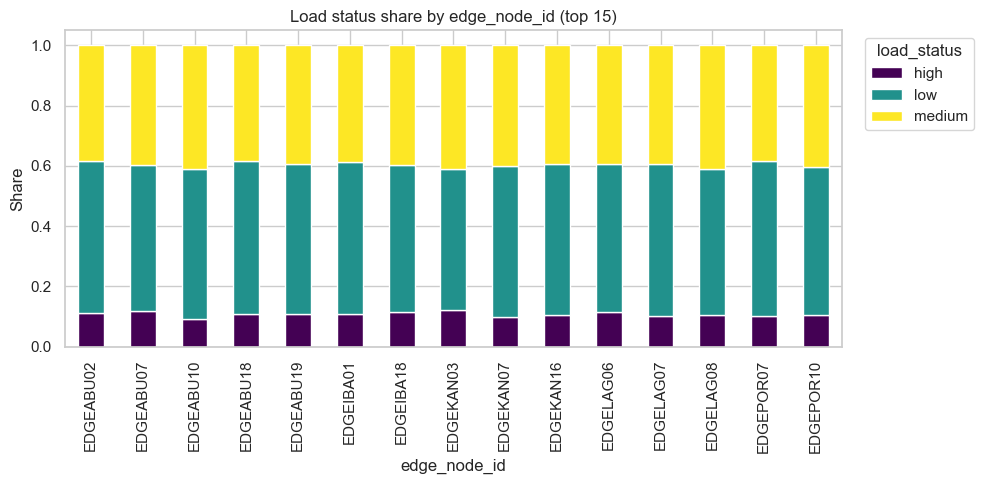

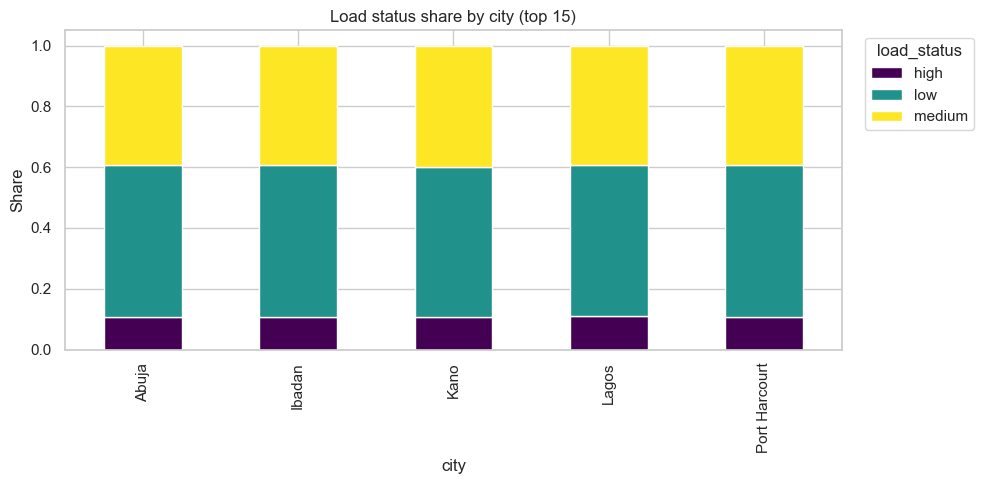

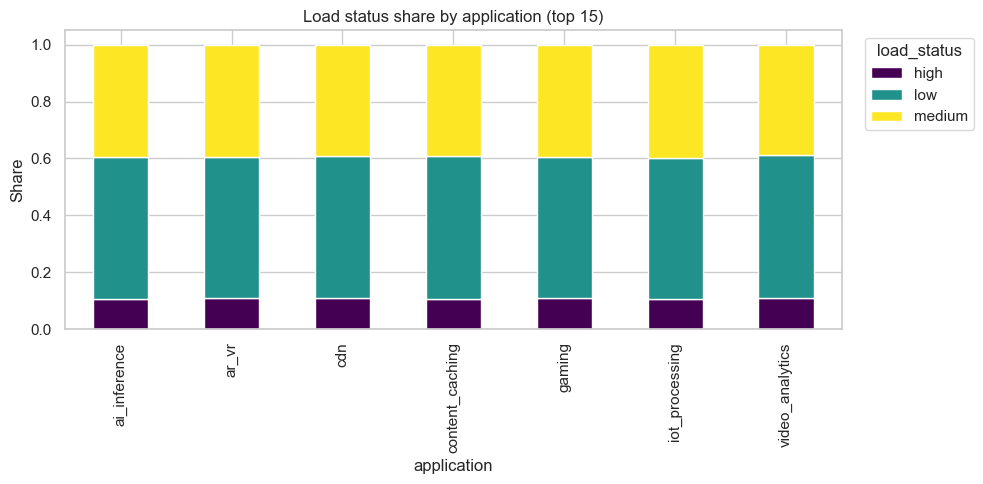

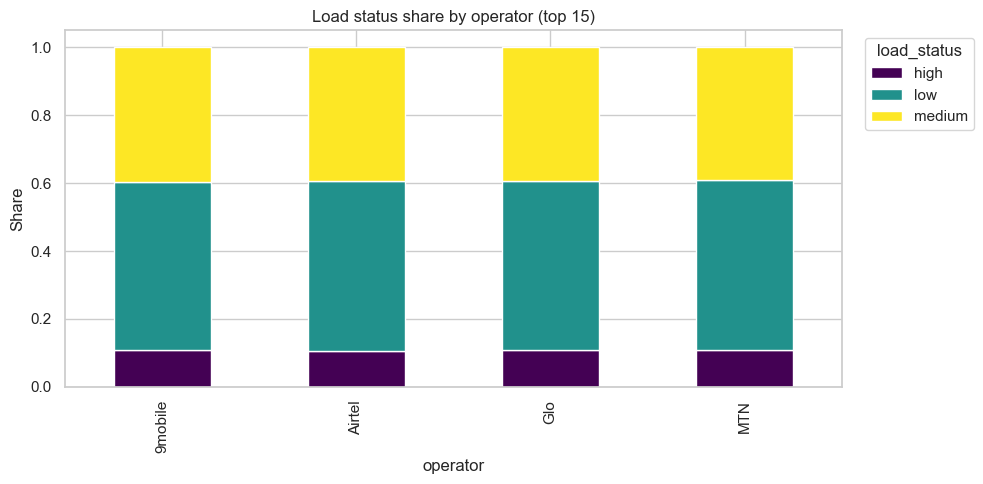

In [86]:
# Categorical distributions — load_status share by top categories
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else None
    topn = 15
    for col in [c for c in cat_cols if c in df.columns]:
        # Limit to top categories to keep plots legible
        top_vals = df[col].value_counts().head(topn).index
        temp = df[df[col].isin(top_vals)]
        if temp.empty:
            continue
        ct = pd.crosstab(temp[col].astype(str), temp['load_status'], normalize='index')
        if order is not None:
            ct = ct.reindex(columns=[c for c in order if c in ct.columns])
        ax = ct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
        plt.title(f"Load status share by {col} (top {topn})")
        plt.ylabel('Share')
        plt.xlabel(col)
        plt.legend(title='load_status', bbox_to_anchor=(1.02, 1), loc='upper left')
        maybe_savefig(f"status_share_{col}")
        plt.show()

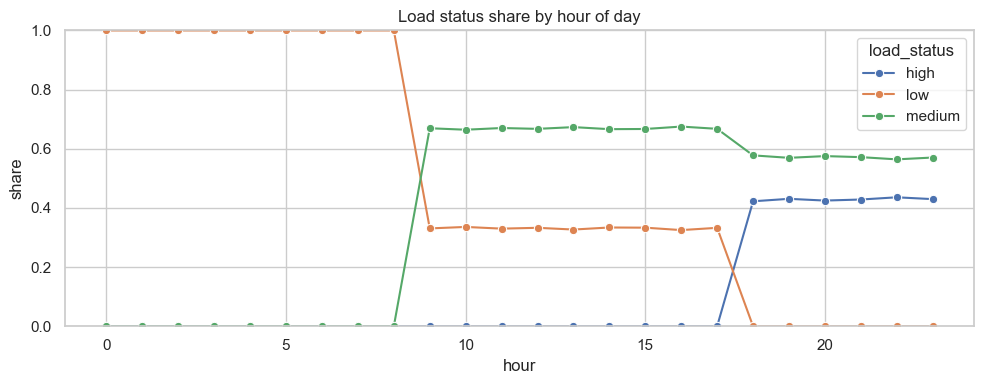

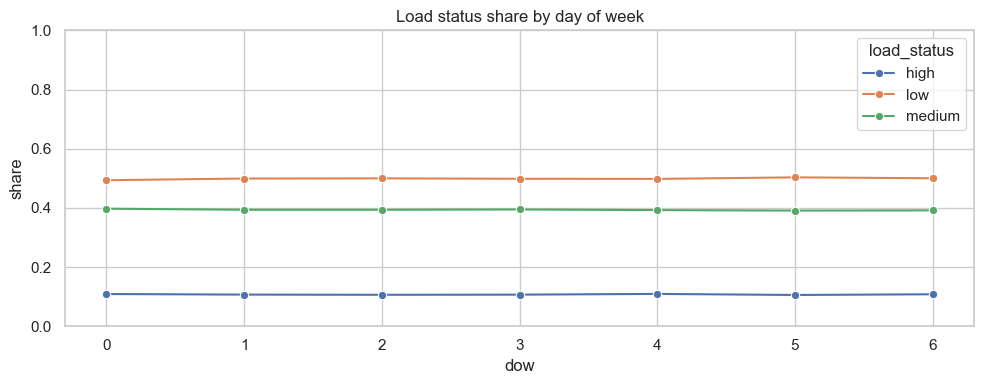

In [87]:
# Time-based: load_status share by hour and day-of-week
if 'timestamp' not in df.columns or df['timestamp'].notna().sum() == 0 or 'load_status' not in df.columns:
    print("Missing timestamp or load_status for time-based plots.")
else:
    tmp = df[df['timestamp'].notna()].copy()
    tmp['hour'] = tmp['timestamp'].dt.hour
    tmp['dow'] = tmp['timestamp'].dt.dayofweek
    dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    tmp['dow_name'] = tmp['dow'].map({i:n for i,n in enumerate(dow_names)})

    # Hourly share
    # share_h = (
    #     tmp.groupby(['hour','load_status']).size()
    #       .groupby(level=0).apply(lambda s: s / s.sum())
    #       .rename('share')
    #       .rename_axis(index=[None, None]) 
    #       .reset_index()
    # )
    # plt.figure(figsize=(10,4))
    # sns.lineplot(data=share_h, x='hour', y='share', hue='load_status', marker='o')
    # plt.title('Load status share by hour of day')
    # plt.ylim(0, 1)
    # maybe_savefig('ls_share_by_hour')
    # plt.show()

    counts = tmp.groupby(['hour', 'load_status']).size().reset_index(name='count')
    counts_dow = tmp.groupby(['dow', 'load_status']).size().reset_index(name='count')

    share_h = (
        counts
            .assign(share=lambda df: df['count'] / df.groupby('hour')['count'].transform('sum'))
    )
    plt.figure(figsize=(10,4))
    sns.lineplot(data=share_h, x='hour', y='share', hue='load_status', marker='o')
    plt.title('Load status share by hour of day')
    plt.ylim(0, 1)
    maybe_savefig('ls_share_by_hour')
    plt.show()

    # Day-of-week share
    share_d = (
    counts_dow
        .assign(share=lambda df: df['count'] / df.groupby('dow')['count'].transform('sum'))
    )
    plt.figure(figsize=(10,4))
    sns.lineplot(data=share_d, x='dow', y='share', hue='load_status', marker='o')
    plt.title('Load status share by day of week')
    plt.ylim(0, 1)
    maybe_savefig('ls_share_by_dow')
    plt.show()

In [88]:
# Summary statistics by load_status (median, p90, p95)
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    def summarize(g):
        out = {}
        for col in metrics:
            s = g[col].dropna()
            if s.empty:
                out[(col,'median')] = np.nan
                out[(col,'p90')] = np.nan
                out[(col,'p95')] = np.nan
            else:
                out[(col,'median')] = s.median()
                out[(col,'p90')] = s.quantile(0.90)
                out[(col,'p95')] = s.quantile(0.95)
        return pd.Series(out)
    stats_by_ls = df.groupby('load_status', observed=True).apply(summarize)
    # Flatten columns
    stats_by_ls.columns = [f"{a}_{b}" for a,b in stats_by_ls.columns]
    display(stats_by_ls.round(3))

,cpu_utilization_percent_median,cpu_utilization_percent_p90,cpu_utilization_percent_p95,memory_utilization_percent_median,memory_utilization_percent_p90,memory_utilization_percent_p95,storage_utilization_percent_median,storage_utilization_percent_p90,storage_utilization_percent_p95,network_throughput_gbps_median,...,active_sessions_p95,requests_per_second_median,requests_per_second_p90,requests_per_second_p95,avg_response_time_ms_median,avg_response_time_ms_p90,avg_response_time_ms_p95,cache_hit_ratio_percent_median,cache_hit_ratio_percent_p90,cache_hit_ratio_percent_p95
load_status,,,,,,,,,,,,,,,,,,,,,
high,87.46,93.480,94.25,70.10,86.057,88.06,55.32,74.937,77.46,25.46,...,4772.0,5047.0,9006.0,9490.00,27.38,45.507,47.78,77.535,91.381,93.136
low,39.94,47.981,49.00,32.76,47.880,53.97,55.01,74.970,77.48,25.51,...,1640.0,5064.0,9017.0,9504.00,27.40,45.420,47.67,77.480,91.480,93.268
medium,63.63,74.540,77.30,52.48,78.970,84.61,54.98,75.080,77.57,25.40,...,4366.0,5038.5,9017.0,9507.25,27.48,45.495,47.71,77.500,91.637,93.360


In [89]:
# Automated interpretation: monotonicity of metrics vs load_status (using medians)
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else sorted(df['load_status'].dropna().unique())
    med = df.groupby('load_status', observed=True)[metrics].median()

    def monotonic_label(vals, tol=1e-8):
        inc_non_strict = all(vals[i+1] >= vals[i] - tol for i in range(len(vals)-1))
        dec_non_strict = all(vals[i+1] <= vals[i] + tol for i in range(len(vals)-1))
        inc_strict = any(vals[i+1] > vals[i] + tol for i in range(len(vals)-1))
        dec_strict = any(vals[i+1] < vals[i] - tol for i in range(len(vals)-1))
        if inc_non_strict and inc_strict and not dec_strict:
            return 'increasing'
        if dec_non_strict and dec_strict and not inc_strict:
            return 'decreasing'
        return 'non-monotonic'

    rows = []
    for col in metrics:
        vals = med[col].reindex(order).values.astype(float)
        trend = monotonic_label(vals)
        change = np.nan
        try:
            if np.isfinite(vals[0]) and vals[0] != 0:
                change = 100.0 * (vals[-1] - vals[0]) / abs(vals[0])
        except Exception:
            pass
        rows.append({'metric': col, 'trend': trend, 'start': vals[0], 'end': vals[-1], 'pct_change_low_to_high': change})

    trend_summary = pd.DataFrame(rows)
    display(trend_summary.round(3))

,metric,trend,start,end,pct_change_low_to_high
0,cpu_utilization_percent,non-monotonic,87.460,63.63,-27.247
1,memory_utilization_percent,non-monotonic,70.100,52.48,-25.136
2,storage_utilization_percent,decreasing,55.320,54.98,-0.615
3,network_throughput_gbps,non-monotonic,25.460,25.40,-0.236
4,active_sessions,non-monotonic,2753.500,1408.00,-48.865
5,requests_per_second,non-monotonic,5047.000,5038.50,-0.168
6,avg_response_time_ms,increasing,27.380,27.48,0.365
7,cache_hit_ratio_percent,non-monotonic,77.535,77.50,-0.045


In [90]:
# High-load share by category (top-k)
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    target_high = 'high' if (str(df['load_status'].dtype) == 'category' and 'high' in df['load_status'].cat.categories) else None
    for col in [c for c in ['operator','city','application','edge_node_id'] if c in df.columns]:
        g = df[[col,'load_status']].dropna()
        if g.empty:
            continue
        tab = pd.crosstab(g[col].astype(str), g['load_status'], normalize='index')
        if target_high and target_high in tab.columns:
            tab = tab.sort_values(target_high, ascending=False)
            display(tab.head(10).round(3))
            print(f"Top {col} values by high-load share:\n", tab[target_high].head(10).round(3))
        else:
            display(tab.head(10).round(3))

load_status,high,low,medium
operator,,,
MTN,0.109,0.501,0.391
Glo,0.108,0.498,0.394
9mobile,0.107,0.497,0.395
Airtel,0.106,0.499,0.395


Top operator values by high-load share:
 operator
MTN        0.109
Glo        0.108
9mobile    0.107
Airtel     0.106
Name: high, dtype: float64


load_status,high,low,medium
city,,,
Lagos,0.110,0.498,0.392
Abuja,0.108,0.501,0.392
Ibadan,0.107,0.501,0.392
Port Harcourt,0.107,0.499,0.394
Kano,0.106,0.495,0.399


Top city values by high-load share:
 city
Lagos            0.110
Abuja            0.108
Ibadan           0.107
Port Harcourt    0.107
Kano             0.106
Name: high, dtype: float64


load_status,high,low,medium
application,,,
video_analytics,0.110,0.501,0.389
cdn,0.109,0.499,0.392
gaming,0.109,0.498,0.393
ar_vr,0.108,0.497,0.396
iot_processing,0.106,0.496,0.399
ai_inference,0.106,0.500,0.394
content_caching,0.105,0.502,0.392


Top application values by high-load share:
 application
video_analytics    0.110
cdn                0.109
gaming             0.109
ar_vr              0.108
iot_processing     0.106
ai_inference       0.106
content_caching    0.105
Name: high, dtype: float64


load_status,high,low,medium
edge_node_id,,,
EDGELAG04,0.121,0.493,0.387
EDGEKAN03,0.121,0.470,0.410
EDGEABU05,0.120,0.496,0.384
EDGEABU07,0.120,0.485,0.396
EDGEKAN12,0.119,0.503,0.379
EDGEIBA07,0.118,0.492,0.389
EDGEPOR17,0.118,0.501,0.381
EDGEKAN05,0.117,0.501,0.382
EDGEPOR11,0.116,0.498,0.385


Top edge_node_id values by high-load share:
 edge_node_id
EDGELAG04    0.121
EDGEKAN03    0.121
EDGEABU05    0.120
EDGEABU07    0.120
EDGEKAN12    0.119
EDGEIBA07    0.118
EDGEPOR17    0.118
EDGEKAN05    0.117
EDGEPOR11    0.116
EDGEABU14    0.116
Name: high, dtype: float64


In [91]:
# Automated textual interpretation
if 'load_status' not in df.columns:
    print("Target 'load_status' not found.")
else:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else sorted(df['load_status'].dropna().unique())
    highest_label = None
    if str(df['load_status'].dtype) == 'category' and order:
        highest_label = order[-1]
    elif 'high' in df['load_status'].astype(str).unique():
        highest_label = 'high'

    # Recompute medians for robustness
    med = df.groupby('load_status', observed=True)[metrics].median()

    def monotonic_label(vals, tol=1e-8):
        inc_non_strict = all(vals[i+1] >= vals[i] - tol for i in range(len(vals)-1))
        dec_non_strict = all(vals[i+1] <= vals[i] + tol for i in range(len(vals)-1))
        inc_strict = any(vals[i+1] > vals[i] + tol for i in range(len(vals)-1))
        dec_strict = any(vals[i+1] < vals[i] - tol for i in range(len(vals)-1))
        if inc_non_strict and inc_strict and not dec_strict:
            return 'increasing'
        if dec_non_strict and dec_strict and not inc_strict:
            return 'decreasing'
        return 'non-monotonic'

    trends = []
    for col in metrics:
        seq = med[col].reindex(order).values.astype(float)
        trend = monotonic_label(seq)
        trends.append((col, trend, seq[0] if len(seq)>0 else np.nan, seq[-1] if len(seq)>0 else np.nan))

    print("\n=== Metric trends vs load_status (median) ===")
    for col, trend, s0, s1 in trends:
        print(f"- {col}: {trend} (low→high: {s0:.3f} → {s1:.3f})")

    if highest_label is not None:
        print("\n=== Top categories by high-load share ===")
        for col in [c for c in ['operator','city','application','edge_node_id'] if c in df.columns]:
            g = df[[col,'load_status']].dropna()
            if g.empty:
                continue
            tab = pd.crosstab(g[col].astype(str), g['load_status'], normalize='index')
            if highest_label in tab.columns:
                top = tab.sort_values(highest_label, ascending=False)[highest_label].head(10)
                print(f"- {col}:\n" + "\n".join([f"  • {idx}: {val:.3f}" for idx, val in top.items()]))

    # Time windows where high-load share is highest
    if 'timestamp' in df.columns and df['timestamp'].notna().sum() > 0 and highest_label is not None:
        tmp = df[df['timestamp'].notna()].copy()
        tmp['hour'] = tmp['timestamp'].dt.hour
        tmp['dow'] = tmp['timestamp'].dt.dayofweek
        dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
        tmp['dow_name'] = tmp['dow'].map({i:n for i,n in enumerate(dow_names)})

        # Hourly share (robust, avoids reset_index issues)
        counts = tmp.groupby(['hour', 'load_status']).size().reset_index(name='count')
        share_h = counts.assign(share=lambda d: d['count'] / d.groupby('hour')['count'].transform('sum'))
        share_high_h = share_h[share_h['load_status'] == highest_label].sort_values('share', ascending=False)

        # Day-of-week share (robust)
        counts_dow = tmp.groupby(['dow_name', 'load_status']).size().reset_index(name='count')
        share_d = counts_dow.assign(share=lambda d: d['count'] / d.groupby('dow_name')['count'].transform('sum'))
        share_high_d = share_d[share_d['load_status'] == highest_label].sort_values('share', ascending=False)

        print("\n=== Peak high-load windows ===")
        print("- Hours with highest high-load share:")
        print(share_high_h[['hour','share']].head(10).to_string(index=False))
        print("- Days with highest high-load share:")
        print(share_high_d[['dow_name','share']].head(7).to_string(index=False))


=== Metric trends vs load_status (median) ===
- cpu_utilization_percent: non-monotonic (low→high: 87.460 → 63.630)
- memory_utilization_percent: non-monotonic (low→high: 70.100 → 52.480)
- storage_utilization_percent: decreasing (low→high: 55.320 → 54.980)
- network_throughput_gbps: non-monotonic (low→high: 25.460 → 25.400)
- active_sessions: non-monotonic (low→high: 2753.500 → 1408.000)
- requests_per_second: non-monotonic (low→high: 5047.000 → 5038.500)
- avg_response_time_ms: increasing (low→high: 27.380 → 27.480)
- cache_hit_ratio_percent: non-monotonic (low→high: 77.535 → 77.500)

=== Top categories by high-load share ===
- operator:
  • 9mobile: 0.395
  • Airtel: 0.395
  • Glo: 0.394
  • MTN: 0.391
- city:
  • Kano: 0.399
  • Port Harcourt: 0.394
  • Lagos: 0.392
  • Ibadan: 0.392
  • Abuja: 0.392
- application:
  • iot_processing: 0.399
  • ar_vr: 0.396
  • ai_inference: 0.394
  • gaming: 0.393
  • content_caching: 0.392
  • cdn: 0.392
  • video_analytics: 0.389
- edge_node_id:

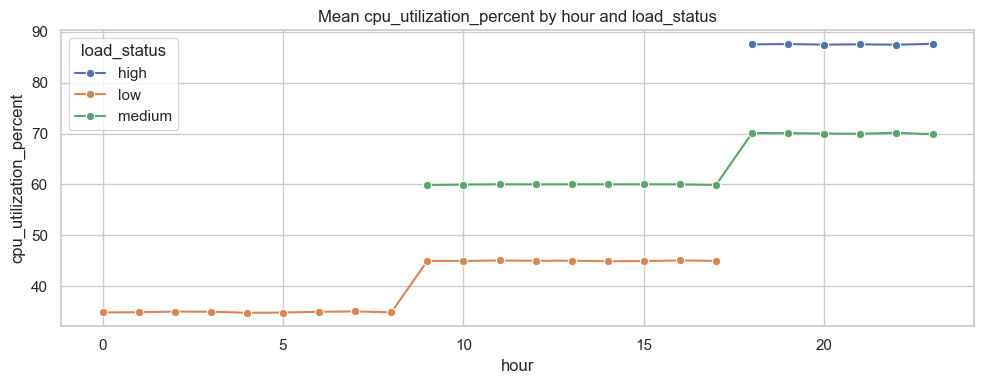

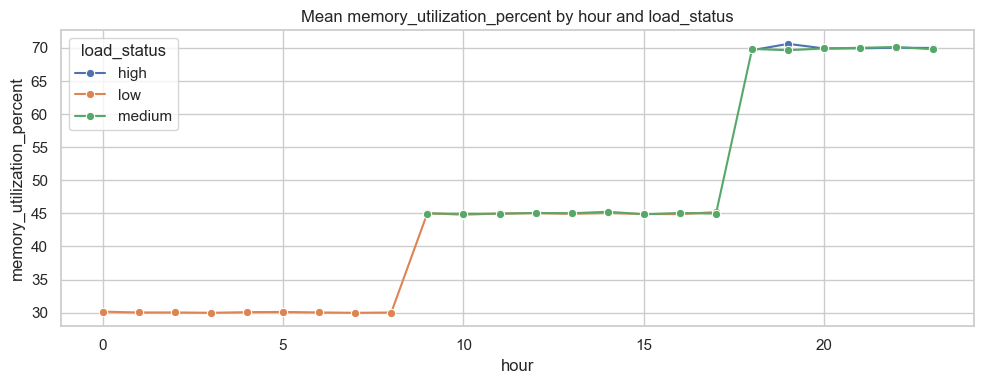

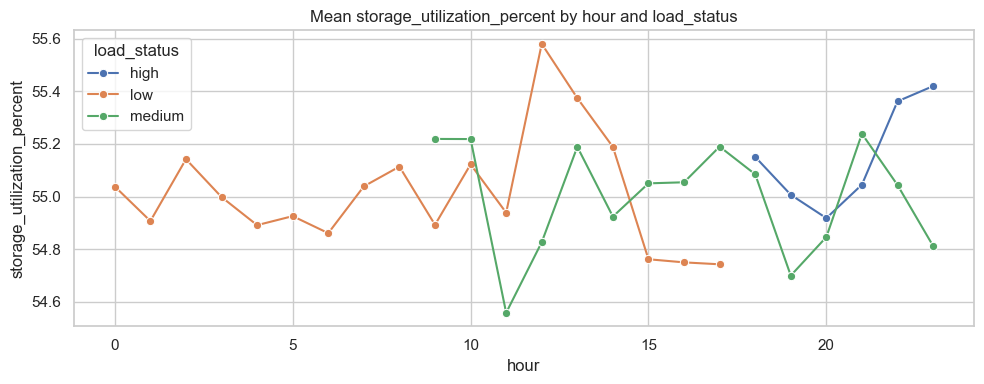

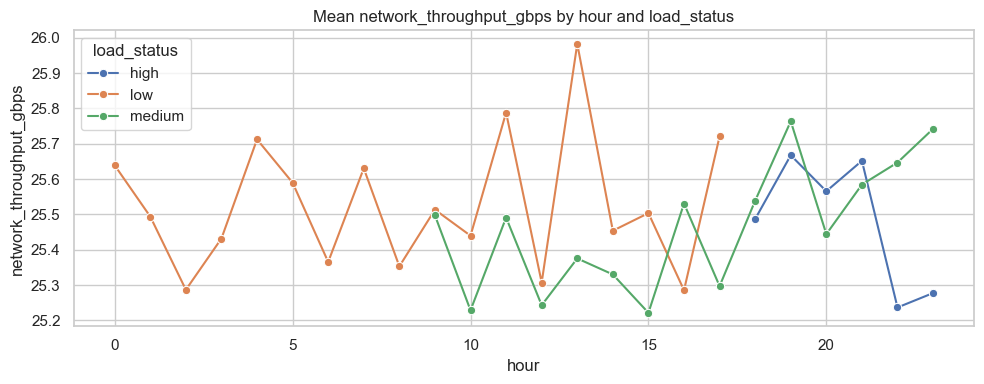

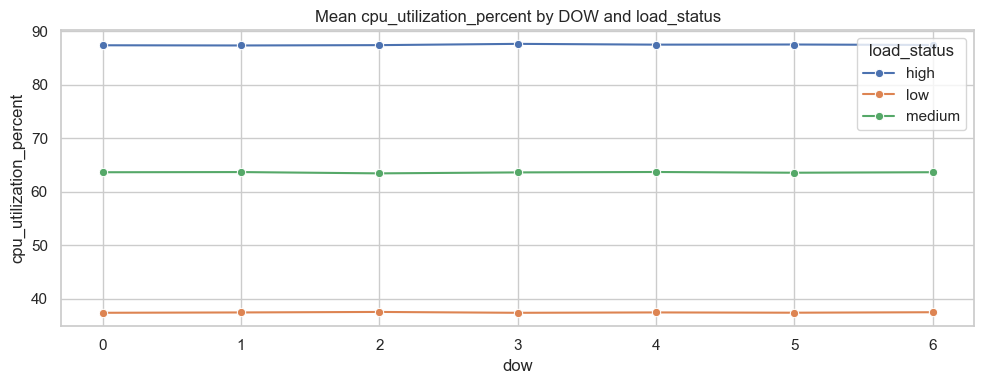

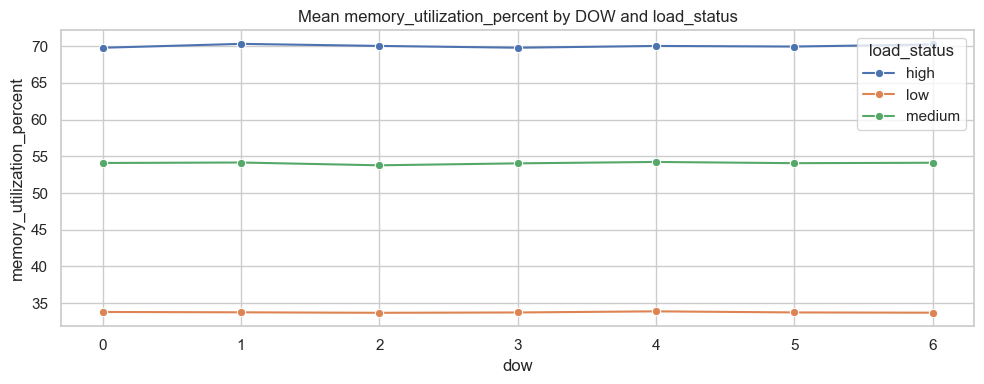

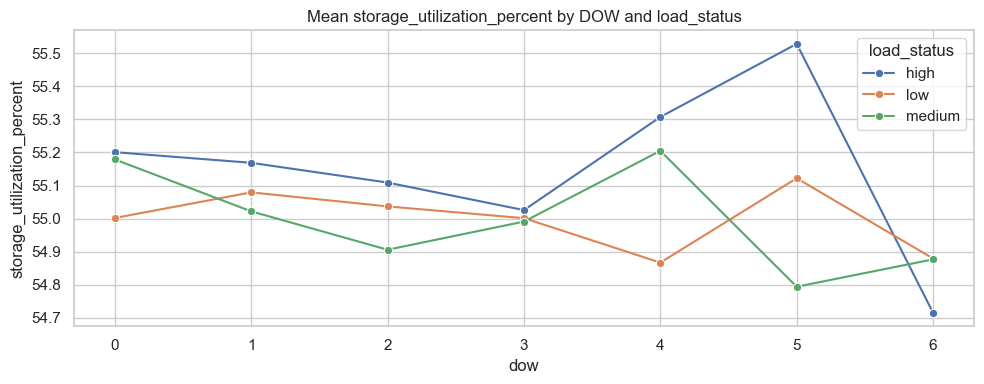

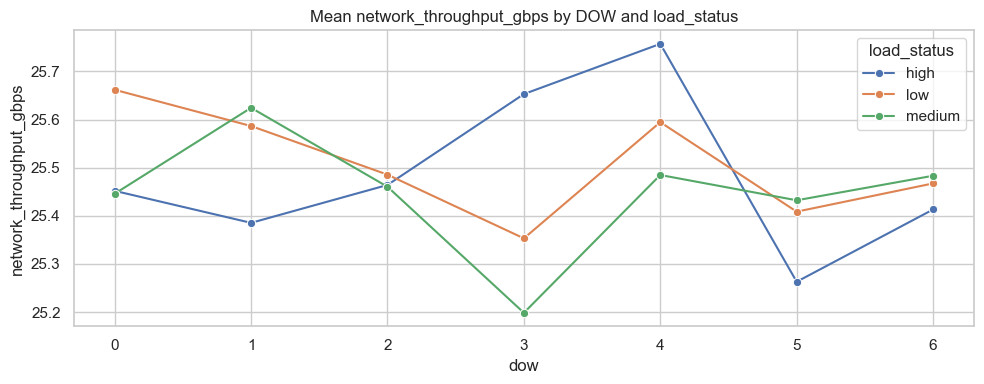

In [92]:
# Time-based: mean metrics by hour and day-of-week, split by load_status
if 'timestamp' not in df.columns or df['timestamp'].notna().sum() == 0 or 'load_status' not in df.columns:
    print("Missing timestamp or load_status for time-based means.")
else:
    tmp = df[df['timestamp'].notna()].copy()
    tmp['hour'] = tmp['timestamp'].dt.hour
    tmp['dow'] = tmp['timestamp'].dt.dayofweek
    dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    tmp['dow_name'] = tmp['dow'].map({i:n for i,n in enumerate(dow_names)})

    subset = metrics[:4] if len(metrics) > 4 else metrics

    # Hourly means
    mean_h = tmp.groupby(['hour','load_status'], observed=True)[subset].mean().reset_index()
    for m in subset:
        plt.figure(figsize=(10,4))
        sns.lineplot(data=mean_h, x='hour', y=m, hue='load_status', marker='o')
        plt.title(f"Mean {m} by hour and load_status")
        maybe_savefig(f"mean_{m}_by_hour_status")
        plt.show()

    # DOW means
    mean_d = tmp.groupby(['dow','load_status'], observed=True)[subset].mean().reset_index()
    for m in subset:
        plt.figure(figsize=(10,4))
        sns.lineplot(data=mean_d, x='dow', y=m, hue='load_status', marker='o')
        plt.title(f"Mean {m} by DOW and load_status")
        maybe_savefig(f"mean_{m}_by_dow_status")
        plt.show()

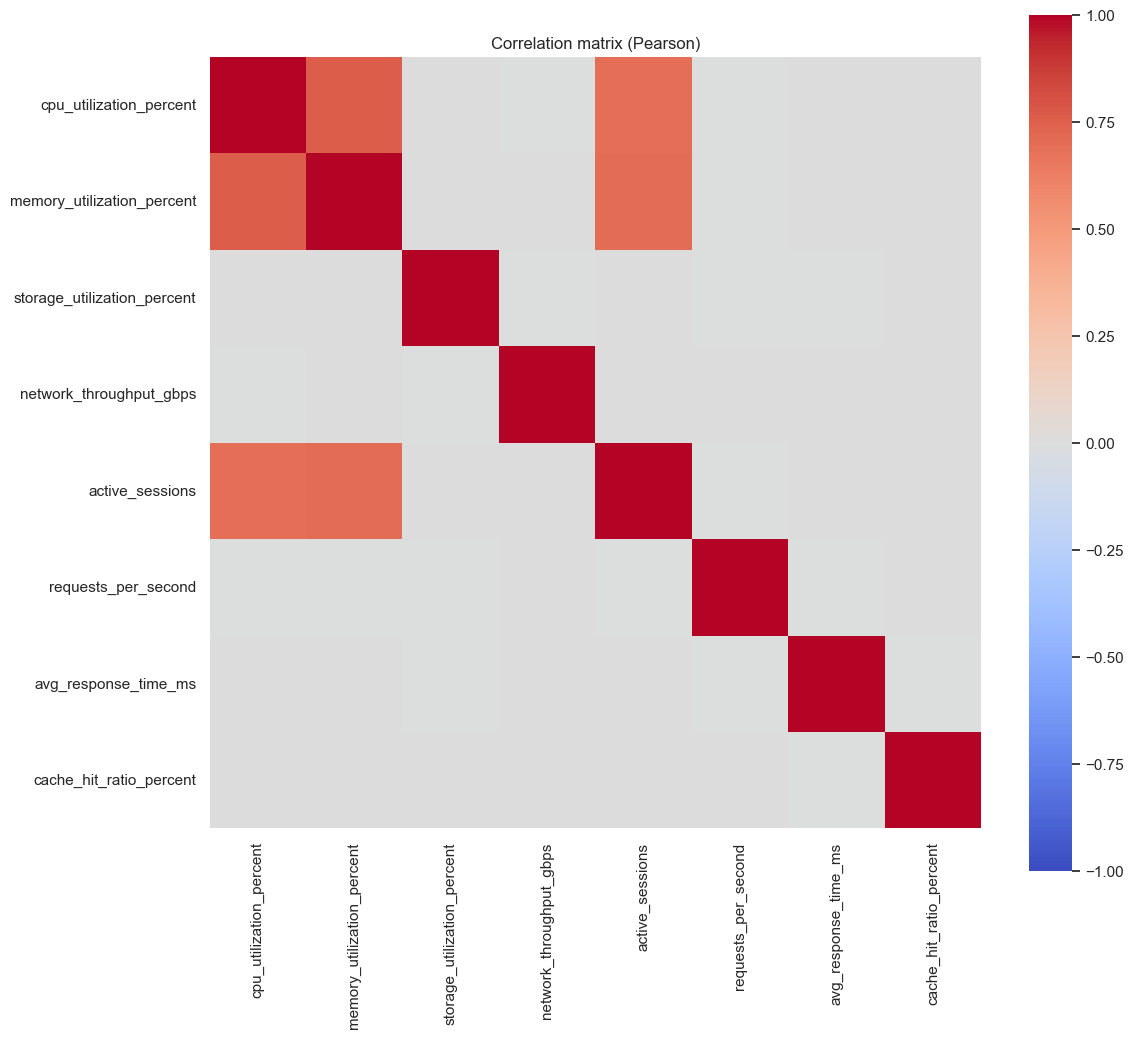

In [93]:
# Correlation matrix (numeric features)
if len(numeric_cols) == 0:
    print("No numeric columns found for correlation.")
else:
    corr = df[numeric_cols].corr(method='pearson')
    size = min(int(1.2*len(numeric_cols) + 3), 18)
    plt.figure(figsize=(size, size))
    sns.heatmap(corr, vmin=-1, vmax=1, cmap='coolwarm', center=0, annot=False,
                square=True, cbar_kws={'shrink': 0.75})
    plt.title('Correlation matrix (Pearson)')
    maybe_savefig('corr_matrix_pearson')
    plt.show()

In [94]:
# Export interpretations to Markdown report (with operator-focused context, column descriptions, and operator conclusions)
out_path = Path("../reports/visualization_interpretations.md")
out_path.parent.mkdir(parents=True, exist_ok=True)

lines = []
lines.append("# Visualization Interpretations\n")
lines.append(f"Generated: {pd.Timestamp.utcnow().strftime('%Y-%m-%d %H:%M:%SZ')} UTC\n")

# Dataset summary
shape_txt = f"Rows: {df.shape[0]}, Columns: {df.shape[1]}"
lines.append("## Dataset Summary\n")
lines.append(f"- **Shape**: {shape_txt}")
# compute numeric/categorical cols if not present
try:
    numeric_cols
except NameError:
    import numpy as _np
    numeric_cols = df.select_dtypes(include=[_np.number]).columns.tolist()
cat_list = [c for c in df.columns if str(df[c].dtype)=='category']
lines.append(f"- **Numeric columns**: {', '.join(numeric_cols) if len(numeric_cols)>0 else 'None'}")
lines.append(f"- **Categorical columns**: {', '.join(cat_list)}\n")

# Column descriptions
COL_DESCRIPTIONS = {
    'edge_node_id': 'Unique identifier for the edge node (string; e.g., EDGELAG04).',
    'operator': 'Telecom operator managing the node (e.g., MTN, Airtel, Glo, 9mobile).',
    'city': 'City where the edge node is located (category; e.g., Lagos, Abuja).',
    'application': 'Workload/application category running on the node (e.g., video_analytics, cdn, gaming, ai_inference, ar_vr, iot_processing, content_caching).',
    'timestamp': 'UTC timestamp when the measurement was recorded (datetime).',
    'load_status': 'Discrete load class label (low, medium, high).',
    'cpu_utilization_percent': 'CPU utilization in percent [0–100].',
    'memory_utilization_percent': 'Memory utilization in percent [0–100].',
    'storage_utilization_percent': 'Storage utilization in percent [0–100].',
    'network_throughput_gbps': 'Observed network throughput in gigabits per second.',
    'active_sessions': 'Concurrent active user/device sessions (count).',
    'requests_per_second': 'Requests handled per second (rate).',
    'avg_response_time_ms': 'Average response latency in milliseconds.',
    'cache_hit_ratio_percent': 'Cache hit ratio in percent [0–100].',
}
col_order = [
    'edge_node_id','operator','city','application','timestamp','load_status',
    'cpu_utilization_percent','memory_utilization_percent','storage_utilization_percent',
    'network_throughput_gbps','active_sessions','requests_per_second',
    'avg_response_time_ms','cache_hit_ratio_percent'
]

present_cols = [c for c in col_order if c in df.columns]
if present_cols:
    lines.append("## Dataset Column Descriptions\n")
    for c in present_cols:
        desc = COL_DESCRIPTIONS.get(c, '')
        lines.append(f"- **{c}**: {desc}")
    lines.append("")

# Target distribution
if 'load_status' in df.columns:
    lines.append("## Target Distribution (load_status)\n")
    counts = df['load_status'].value_counts(dropna=False)
    props = df['load_status'].value_counts(normalize=True, dropna=False)
    for idx in counts.index:
        lines.append(f"- **{idx}**: {int(counts[idx])} ({props[idx]:.3%})")
    lines.append("")

# Metrics selection safeguard
try:
    metrics
except NameError:
    preferred = [
        'cpu_utilization_percent','memory_utilization_percent','storage_utilization_percent',
        'network_throughput_gbps','active_sessions','requests_per_second',
        'avg_response_time_ms','cache_hit_ratio_percent'
    ]
    metrics = [c for c in preferred if c in df.columns] or numeric_cols

# Metric trends using medians
if 'load_status' in df.columns and len(metrics)>0:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else sorted(df['load_status'].dropna().unique())
    med = df.groupby('load_status', observed=True)[metrics].median()

    def monotonic_label(vals, tol=1e-8):
        inc_non_strict = all(vals[i+1] >= vals[i] - tol for i in range(len(vals)-1))
        dec_non_strict = all(vals[i+1] <= vals[i] + tol for i in range(len(vals)-1))
        inc_strict = any(vals[i+1] > vals[i] + tol for i in range(len(vals)-1))
        dec_strict = any(vals[i+1] < vals[i] - tol for i in range(len(vals)-1))
        if inc_non_strict and inc_strict and not dec_strict:
            return 'increasing'
        if dec_non_strict and dec_strict and not inc_strict:
            return 'decreasing'
        return 'non-monotonic'

    lines.append("## Metric Trends vs load_status (median)\n")
    for col in metrics:
        vals = med[col].reindex(order).values.astype(float)
        trend = monotonic_label(vals)
        try:
            s0 = f"{vals[0]:.3f}"; s1 = f"{vals[-1]:.3f}"
        except Exception:
            s0 = s1 = "nan"
        lines.append(f"- **{col}**: {trend} (low→high: {s0} → {s1})")
    lines.append("")

# Determine the highest label name
highest_label = None
if 'load_status' in df.columns:
    order = list(df['load_status'].cat.categories) if str(df['load_status'].dtype) == 'category' else sorted(df['load_status'].dropna().unique())
    if str(df['load_status'].dtype) == 'category' and order:
        highest_label = order[-1]
    elif 'high' in df['load_status'].astype(str).unique():
        highest_label = 'high'

# High-load share by category
if 'load_status' in df.columns and highest_label is not None:
    lines.append("## Categories with Highest High-Load Share\n")
    for col in [c for c in ['operator','city','application','edge_node_id'] if c in df.columns]:
        g = df[[col,'load_status']].dropna()
        if g.empty:
            continue
        tab = pd.crosstab(g[col].astype(str), g['load_status'], normalize='index')
        if highest_label in tab.columns:
            top = tab.sort_values(highest_label, ascending=False)[highest_label].head(10)
            lines.append(f"- **{col}** (top 10):")
            for idx, val in top.items():
                lines.append(f"  - {idx}: {val:.3f}")
    lines.append("")

# Time windows with highest high-load share
if 'timestamp' in df.columns and df['timestamp'].notna().sum() > 0 and 'load_status' in df.columns and highest_label is not None:
    tmp = df[df['timestamp'].notna()].copy()
    tmp['hour'] = tmp['timestamp'].dt.hour
    tmp['dow'] = tmp['timestamp'].dt.dayofweek
    dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    tmp['dow_name'] = tmp['dow'].map({i:n for i,n in enumerate(dow_names)})

    counts_h = tmp.groupby(['hour','load_status']).size().reset_index(name='count')
    share_high_h = (
        counts_h.assign(share=lambda d: d['count'] / d.groupby('hour')['count'].transform('sum'))
                 .query('load_status == @highest_label')
                 .sort_values('share', ascending=False)
    )

    counts_d = tmp.groupby(['dow_name','load_status']).size().reset_index(name='count')
    share_high_d = (
        counts_d.assign(share=lambda d: d['count'] / d.groupby('dow_name')['count'].transform('sum'))
                 .query('load_status == @highest_label')
                 .sort_values('share', ascending=False)
    )

    lines.append("## Peak High-Load Windows\n")
    lines.append("- **Hours** with highest high-load share:")
    for _, r in share_high_h[['hour','share']].head(10).iterrows():
        lines.append(f"  - Hour {int(r['hour'])}: {r['share']:.3f}")
    lines.append("- **Days** with highest high-load share:")
    for _, r in share_high_d[['dow_name','share']].head(7).iterrows():
        lines.append(f"  - {r['dow_name']}: {r['share']:.3f}")
    lines.append("")

# Correlation insights
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(method='pearson')
    pairs = []
    for i, ci in enumerate(numeric_cols):
        for j in range(i+1, len(numeric_cols)):
            cj = numeric_cols[j]
            val = corr.loc[ci, cj]
            if pd.notna(val):
                pairs.append((ci, cj, float(val)))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

    lines.append("## Correlation Highlights (Pearson)\n")
    topk = 15
    for ci, cj, v in pairs_sorted[:topk]:
        lines.append(f"- {ci} ↔ {cj}: {v:.3f}")
    lines.append("")

# Operator-focused insights
if 'operator' in df.columns and 'load_status' in df.columns:
    lines.append("## Operator-Focused Insights\n")

    # Operator load_status distribution (proportions)
    lines.append("### Operator load_status distribution (proportions)\n")
    op_props = (
        df.groupby('operator')['load_status']
          .value_counts(normalize=True, dropna=False)
          .unstack(fill_value=0)
    )
    if 'load_status' in df.columns and str(df['load_status'].dtype) == 'category':
        ls_cols = [c for c in df['load_status'].cat.categories if c in op_props.columns]
        op_props = op_props.reindex(columns=ls_cols)
    for op, row in op_props.iterrows():
        parts = [f"{c}: {row[c]:.3%}" for c in op_props.columns]
        lines.append(f"- **{op}**: " + ", ".join(parts))
    lines.append("")

    # Per-operator peak windows for high-load
    if 'timestamp' in df.columns and df['timestamp'].notna().sum() > 0 and highest_label is not None:
        lines.append("### Per-operator peak high-load windows\n")
        tmp = df[df['timestamp'].notna()].copy()
        tmp['hour'] = tmp['timestamp'].dt.hour
        tmp['dow'] = tmp['timestamp'].dt.dayofweek
        dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
        tmp['dow_name'] = tmp['dow'].map({i:n for i,n in enumerate(dow_names)})
        for op in sorted(df['operator'].dropna().astype(str).unique()):
            sub = tmp[tmp['operator'].astype(str) == op]
            if sub.empty:
                continue
            counts_h = sub.groupby(['hour','load_status']).size().reset_index(name='count')
            share_high_h = (
                counts_h.assign(share=lambda d: d['count'] / d.groupby('hour')['count'].transform('sum'))
                        .query('load_status == @highest_label')
                        .sort_values('share', ascending=False)
            )
            counts_d = sub.groupby(['dow_name','load_status']).size().reset_index(name='count')
            share_high_d = (
                counts_d.assign(share=lambda d: d['count'] / d.groupby('dow_name')['count'].transform('sum'))
                        .query('load_status == @highest_label')
                        .sort_values('share', ascending=False)
            )
            lines.append(f"- **{op}**:")
            for _, r in share_high_h[['hour','share']].head(5).iterrows():
                lines.append(f"  - Hour {int(r['hour'])}: {r['share']:.3f}")
            parts = ", ".join([f"{r['dow_name']} ({r['share']:.3f})" for _, r in share_high_d[['dow_name','share']].head(7).iterrows()])
            lines.append(f"  - Days: {parts}")
        lines.append("")

    # Per-operator metrics change from low→high (top increases)
    lines.append("### Per-operator metrics with largest low→high increase (median)\n")
    per_op_increases = {}
    for op in sorted(df['operator'].dropna().astype(str).unique()):
        sub = df[df['operator'].astype(str) == op]
        if sub.empty or highest_label is None:
            continue
        try:
            med = sub.groupby('load_status', observed=True)[metrics].median()
        except Exception:
            continue
        if med.empty:
            continue
        inc_rows = []
        for m in metrics:
            vals = med[m]
            if ('low' in vals.index) and (highest_label in vals.index) and pd.notna(vals['low']) and pd.notna(vals[highest_label]):
                s0, s1 = float(vals['low']), float(vals[highest_label])
                pct = None
                if s0 != 0:
                    pct = 100.0 * (s1 - s0) / abs(s0)
                inc_rows.append((m, s0, s1, pct))
        inc_rows = [r for r in inc_rows if r[3] is not None]
        inc_rows.sort(key=lambda x: x[3], reverse=True)
        lines.append(f"- **{op}**:")
        for m, s0, s1, pct in inc_rows[:5]:
            lines.append(f"  - {m}: {s0:.3f} → {s1:.3f} ({pct:.1f}%)")
        per_op_increases[op] = inc_rows
    lines.append("")

    # Per-operator top cities/applications by high-load share
    lines.append("### Per-operator top cities and applications by high-load share\n")
    top_city_by_op = {}
    top_app_by_op = {}
    for op in sorted(df['operator'].dropna().astype(str).unique()):
        sub = df[df['operator'].astype(str) == op]
        lines.append(f"- **{op}**:")
        if 'city' in sub.columns and highest_label is not None:
            t = pd.crosstab(sub['city'].astype(str), sub['load_status'], normalize='index')
            if highest_label in t.columns and not t.empty:
                top = t.sort_values(highest_label, ascending=False)[highest_label].head(5)
                city_parts = ", ".join([f"{idx} ({val:.3f})" for idx, val in top.items()])
                lines.append(f"  - Cities: {city_parts}")
                top_city_by_op[op] = top.index[0]
        if 'application' in sub.columns and highest_label is not None:
            t = pd.crosstab(sub['application'].astype(str), sub['load_status'], normalize='index')
            if highest_label in t.columns and not t.empty:
                top = t.sort_values(highest_label, ascending=False)[highest_label].head(5)
                app_parts = ", ".join([f"{idx} ({val:.3f})" for idx, val in top.items()])
                lines.append(f"  - Apps: {app_parts}")
                top_app_by_op[op] = top.index[0]
    lines.append("")

    # Operator-Level Conclusions
    lines.append("## Operator-Level Conclusions\n")
    # Variation in high-load share across operators
    try:
        op_props2 = (
            df.groupby('operator')['load_status']
              .value_counts(normalize=True, dropna=False)
              .unstack(fill_value=0)
        )
        if highest_label in op_props2.columns:
            hl = op_props2[highest_label]
            min_op = hl.idxmin(); max_op = hl.idxmax()
            min_v = float(hl[min_op]); max_v = float(hl[max_op])
            lines.append(f"- **High-load share varies slightly by operator**: {min_v:.3%} ({min_op}) to {max_v:.3%} ({max_op}).")
    except Exception:
        pass

    # Peak hour clustering across operators
    if 'timestamp' in df.columns and df['timestamp'].notna().sum() > 0 and highest_label is not None:
        tmp2 = df[df['timestamp'].notna()].copy()
        tmp2['hour'] = tmp2['timestamp'].dt.hour
        hours_top = []
        try:
            for op in sorted(df['operator'].dropna().astype(str).unique()):
                sub = tmp2[tmp2['operator'].astype(str) == op]
                if sub.empty:
                    continue
                ch = sub.groupby(['hour','load_status']).size().reset_index(name='count')
                sh = ch.assign(share=lambda d: d['count'] / d.groupby('hour')['count'].transform('sum'))
                shh = sh.query('load_status == @highest_label').sort_values('share', ascending=False)
                if not shh.empty:
                    hours_top.append(int(shh.iloc[0]['hour']))
        except Exception:
            hours_top = []
        if hours_top:
            lines.append(f"- **Peak high-load hours cluster in the evening**: {min(hours_top)}:00–{max(hours_top)}:00 across operators.")

    # Metrics most affected by load escalation
    try:
        from collections import Counter as _Counter
        winners = []
        pct_ranges = {}
        for op, inc_rows in per_op_increases.items():
            for m, s0, s1, pct in inc_rows[:3]:
                winners.append(m)
                if pct is not None:
                    rng = pct_ranges.get(m, [pct, pct])
                    pct_ranges[m] = [min(rng[0], pct), max(rng[1], pct)]
        common = [m for m, _ in _Counter(winners).most_common(3)]
        if common:
            parts = []
            for m in common:
                lo, hi = pct_ranges.get(m, [None, None])
                if lo is not None and hi is not None:
                    parts.append(f"{m} (~{lo:.1f}%→{hi:.1f}% increase)")
                else:
                    parts.append(m)
            lines.append("- **Metrics that rise most from low→high**: " + ", ".join(parts) + ".")
    except Exception:
        pass

    # Recurring hotspots
    try:
        from collections import Counter as _Counter
        if top_city_by_op:
            top_cities = list(top_city_by_op.values())
            city_common = _Counter(top_cities).most_common(2)
            parts = ", ".join([f"{c} ({n} ops)" for c, n in city_common])
            lines.append(f"- **Recurring city hotspots**: {parts}.")
        if top_app_by_op:
            top_apps = list(top_app_by_op.values())
            app_common = _Counter(top_apps).most_common(2)
            parts = ", ".join([f"{a} ({n} ops)" for a, n in app_common])
            lines.append(f"- **Recurring application hotspots**: {parts}.")
    except Exception:
        pass

# Write file
out_path.write_text("\n".join(lines), encoding='utf-8')
print(f"Wrote interpretations to: {out_path.resolve()}")

Wrote interpretations to: C:\Users\Angela.Ebirim\CascadeProjects\edge-load-eda\reports\visualization_interpretations.md
